# Aplicando Filtros no domínio da frequência

## 1. Leitura da imagem a cálculo da transformada de Fourier

Lembrando que sinais digitais são visto como se estivessem repetidos diversas vezes tanto no domínio espacial quanto no da frequência. Portanto, precisamos preencher os sinais com zeros antes de aplicar a filtragem.

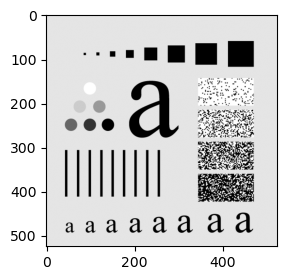

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftfreq, fftshift

img = plt.imread('../../dados/test_image.tiff')
plt.imshow(img, 'gray')

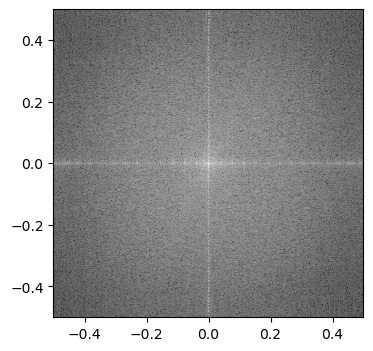

In [9]:
def generate_frequencies(num_rows, num_cols):
    """Gera as frequências correspondentes a cada posição da DFT"""
    freq_r = fftfreq(num_rows)
    freq_c = fftfreq(num_cols)

    freq_r = fftshift(freq_r)
    freq_c = fftshift(freq_c)

    return freq_r, freq_c

def show_fourier_spectrum(freq_r, freq_c, Fimg):
    """Plota o espectro de Fourier da imagem"""
    plt.figure(figsize=[4, 4])
    plt.pcolormesh(freq_c, freq_r, np.log(np.abs(Fimg)+1), cmap='gray')


num_rows, num_cols = img.shape
# Adiciona zeros ao final da imagem, para evitar interferência 
# com as diversas cópias (virtuais) da imagem
img_padded = np.pad(img, ((0, num_rows), (0, num_cols)), 
                    mode='constant', constant_values=0)

Fimg = fft2(img_padded)
Fimg = fftshift(Fimg)
freq_r, freq_c = generate_frequencies(2*num_rows, 2*num_cols)

show_fourier_spectrum(freq_r, freq_c, Fimg)

## 2. Filtro passa-baixa ideal

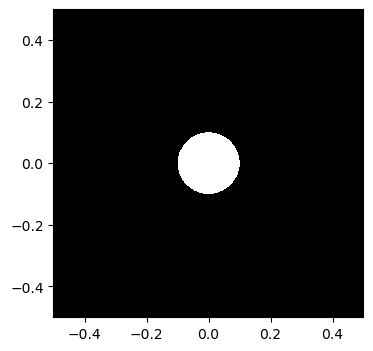

In [10]:
def ideal_low_pass_filter(img, radius):
    """Cria um filtro passa-baixa de mesma dimensão que img. radius define o 
       raio do filtro, isto é, a máxima frequência que será mantida na imagem"""
    num_rows, num_cols = img.shape
    freq_r, freq_c = generate_frequencies(num_rows, num_cols)  
    
    low_pass_filter = np.zeros([num_rows, num_cols])
    for row in range(num_rows):
        for col in range(num_cols):
            distance = np.sqrt(freq_r[row]**2 + freq_c[col]**2)
            if distance<=radius:
                low_pass_filter[row, col] = 1
    return low_pass_filter

lp_filter = ideal_low_pass_filter(img_padded, radius=0.1)
show_fourier_spectrum(freq_r, freq_c, lp_filter)

#### Aplicação do filtro

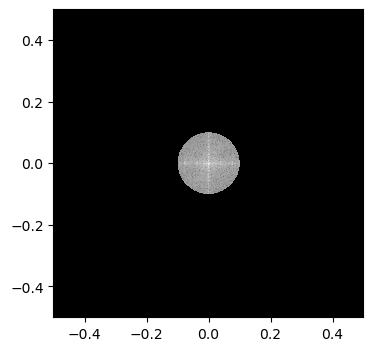

In [11]:
Fimg_filtered = lp_filter*Fimg
show_fourier_spectrum(freq_r, freq_c, Fimg_filtered)

#### Cálculo da transformada inversa para recuperar a imagem após filtragem

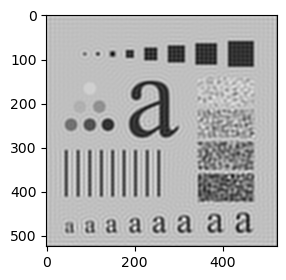

In [12]:
def recover_image_from_spectrum(Fimg):

    # fftshift é utilizado para retornar o espectro para as posições
    # esperadas pela função ifft2
    Fimg = fftshift(Fimg)
    img = ifft2(Fimg)
    # O resultado da transformada inversa de Fourier possui números complexos
    # por causa da precisão finita do computador. Isso não deveria ocorrer.
    # Portanto, mantemos apenas a parte real do resultado
    img = np.real(img)
    # Seleciona imagem final no quadrante superior esquerdo
    img = img[:num_rows, :num_cols]

    return img

img_filtered = recover_image_from_spectrum(Fimg_filtered)
plt.imshow(img_filtered, 'gray')